In [ ]:
import pandas as pd

data = pd.read_csv('/insurance.csv')

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
numerical_features = ['age', 'bmi', 'charges']
categorical_features = ['sex', 'smoker', 'region']

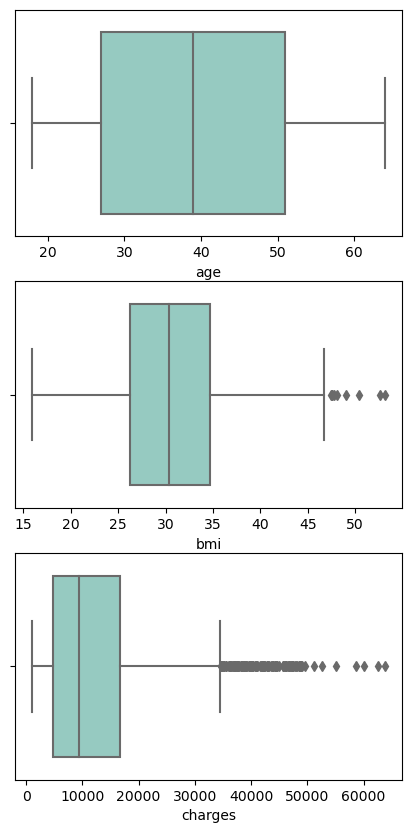

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Menampilkan boxplot untuk seluruh kolom
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 10))
for i, column in enumerate(numerical_features):
    sns.boxplot(ax=axes[i], x=data[column], palette='Set3')
    axes[i].set_xlabel(column)

plt.show()

In [ ]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR=Q3-Q1
data=data[~((data<(Q1-1.5*IQR))|(data>(Q3+1.5*IQR))).any(axis=1)]

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version.  Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  after removing the cwd from sys.path.


In [ ]:
data.shape

(1193, 7)

        jumlah sampel  persentase
female            611        51.2
male              582        48.8


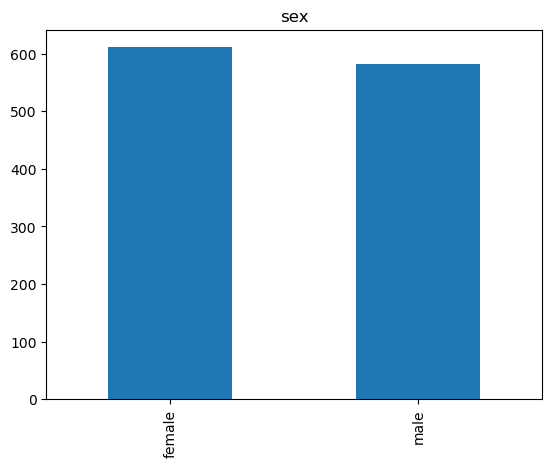

     jumlah sampel  persentase
no            1055        88.4
yes            138        11.6


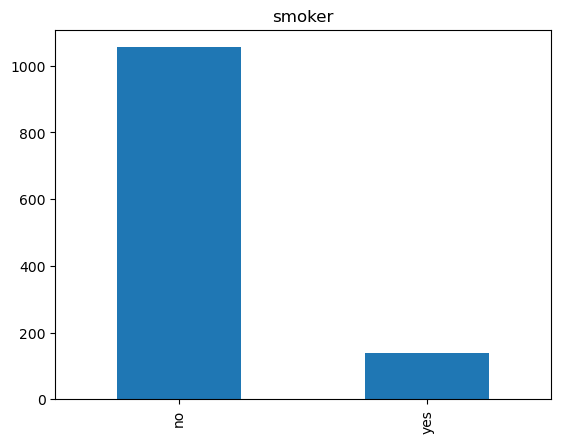

           jumlah sampel  persentase
northwest            305        25.6
southeast            302        25.3
northeast            295        24.7
southwest            291        24.4


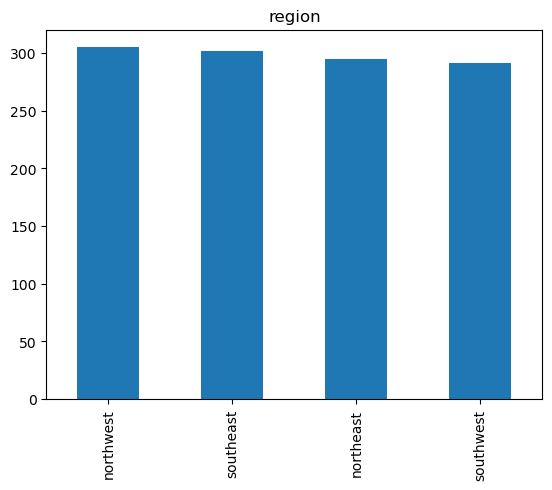

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_categorical(data, categorical_features):
    for feature in categorical_features[:3]:
        count = data[feature].value_counts()
        percent = 100*data[feature].value_counts(normalize=True)
        df = pd.DataFrame({'jumlah sampel':count, 'persentase':percent.round(1)})
        print(df)
        count.plot(kind='bar', title=feature)
        plt.show()
plot_categorical(data, categorical_features)

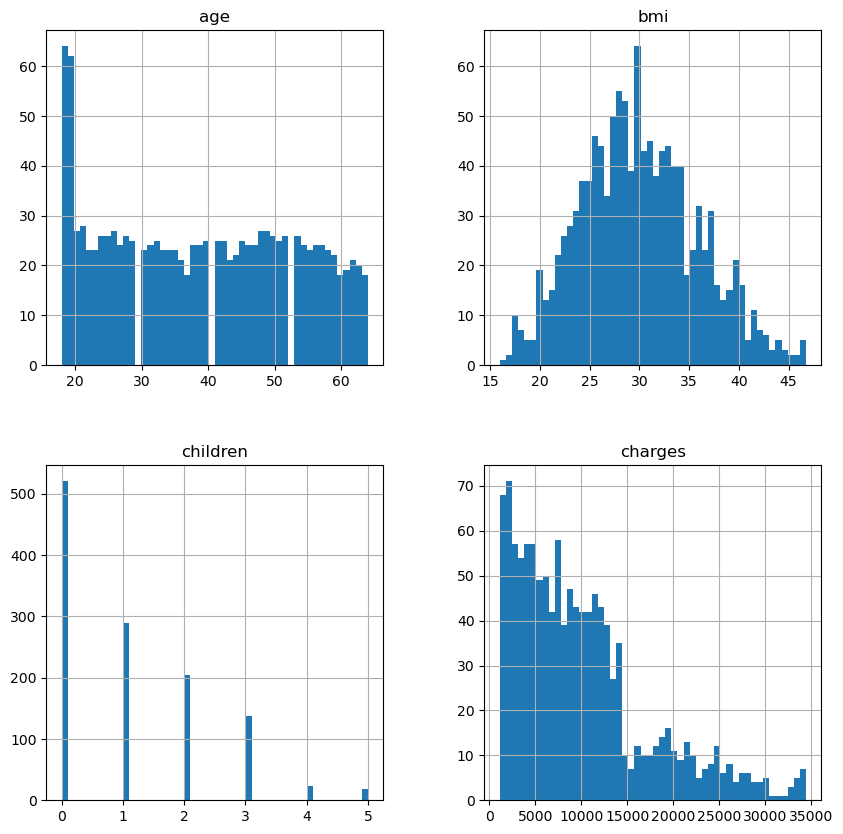

In [ ]:
data.hist(bins=50, figsize=(10,10))
plt.show()

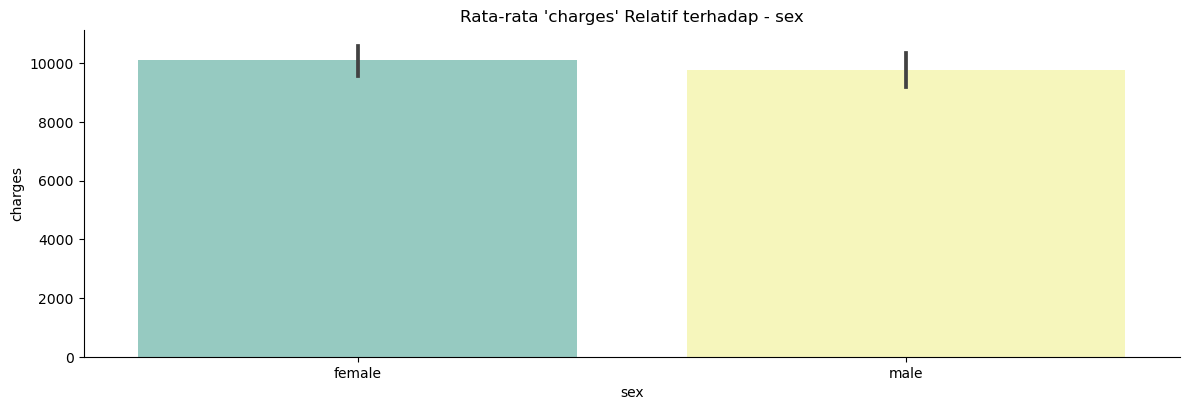

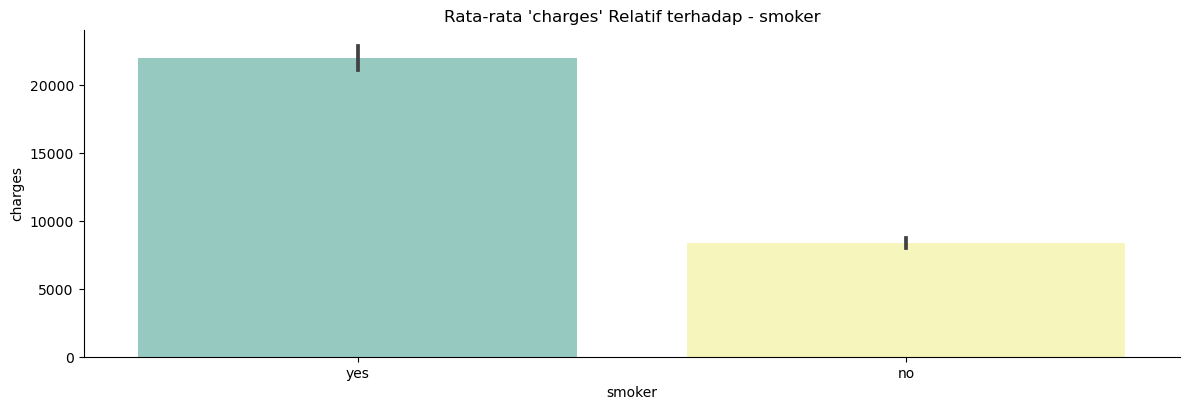

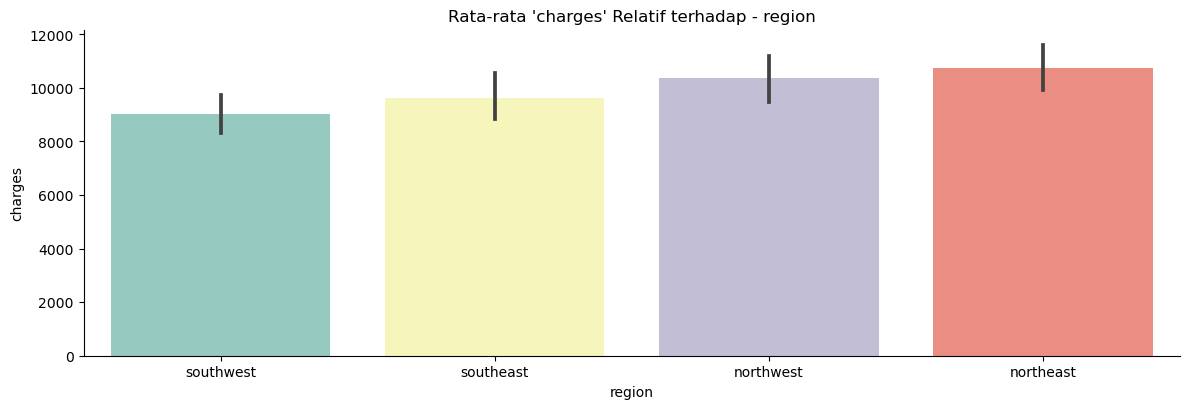

In [ ]:
cat_features = data.select_dtypes(include='object').columns.to_list()

for col in cat_features:
  sns.catplot(x=col, y="charges", kind="bar", dodge=False, height = 4, aspect = 3,  data=data, palette="Set3")
  plt.title("Rata-rata 'charges' Relatif terhadap - {}".format(col))

Text(0.5, 1.0, 'Correlation Matrix untuk Fitur Numerik ')

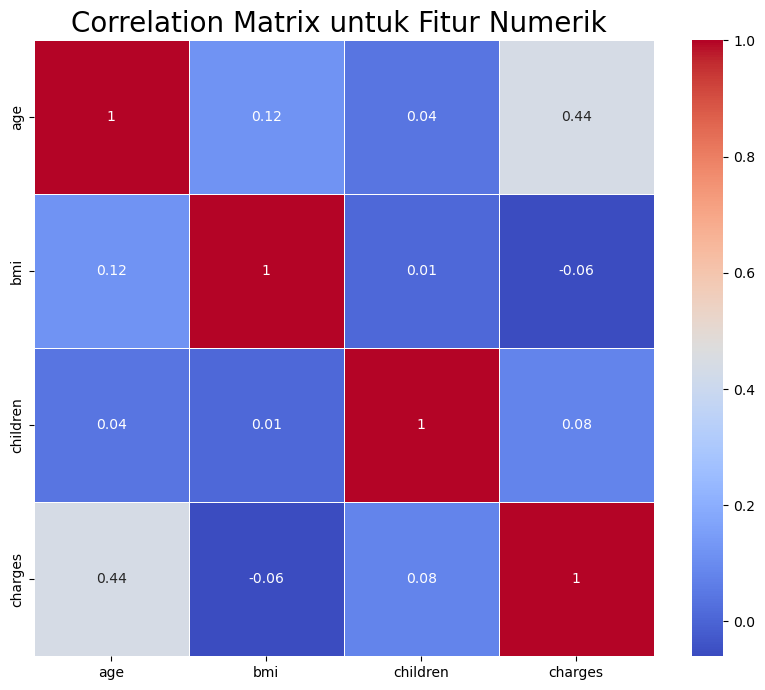

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr().round(2)

# Untuk menge-print nilai di dalam kotak, gunakan parameter anot=True
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Correlation Matrix untuk Fitur Numerik ", size=20)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(data, columns):
    encoder = OneHotEncoder(handle_unknown='ignore')
    encoded = encoder.fit_transform(data[columns])
    labels = encoder.get_feature_names_out(columns)
    encoded_df = pd.DataFrame(encoded.toarray(), columns=labels)
    data = pd.concat([data.drop(columns, axis=1), encoded_df], axis=1)
    return data

In [ ]:
data = one_hot_encode(data, categorical_features)

data.head()

,age,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18.0,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28.0,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33.0,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32.0,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
null_counts = data.isnull().sum()
print(null_counts)

age                 129
charges             129
sex_female          129
sex_male            129
smoker_no           129
smoker_yes          129
region_northeast    129
region_northwest    129
region_southeast    129
region_southwest    129
dtype: int64


In [ ]:
data = data.dropna()
data.shape

(1064, 10)

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(["charges"],axis =1)
y = data["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)

In [ ]:
print(f'Total # of sample in whole dataset: {len(X)}')
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Total # of sample in test dataset: {len(X_test)}')

Total # of sample in whole dataset: 1064
Total # of sample in train dataset: 851
Total # of sample in test dataset: 213


In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['age']
scaler = StandardScaler()
scaler.fit(X_train[numerical_features])
X_train[numerical_features] = scaler.transform(X_train.loc[:, numerical_features])
X_train[numerical_features].head()

,age
51,-1.329346
869,-1.045445
613,-0.406669
630,0.941860
1126,1.083810


In [ ]:
X_train[numerical_features].describe().round(2)

,age
count,851.00
mean,0.00
std,1.00
min,-1.54
25%,-0.90
50%,0.09
75%,0.87
max,1.72


In [ ]:
# Siapkan dataframe untuk analisis model
models = pd.DataFrame(index=['train_mse', 'test_mse'],
                      columns=['KNN', 'RandomForest', 'Boosting'])

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

models.loc['train_mse','knn'] = mean_squared_error(y_pred = knn.predict(X_train), y_true=y_train)

In [ ]:
# Impor library yang dibutuhkan
from sklearn.ensemble import RandomForestRegressor

# buat model prediksi
RF = RandomForestRegressor(n_estimators=100, max_depth=35, random_state=123, n_jobs=-1)
RF.fit(X_train, y_train)

models.loc['train_mse','RandomForest'] = mean_squared_error(y_pred=RF.predict(X_train), y_true=y_train)

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

boosting = AdaBoostRegressor(learning_rate=0.05, random_state=55)
boosting.fit(X_train, y_train)
models.loc['train_mse','Boosting'] = mean_squared_error(y_pred=boosting.predict(X_train), y_true=y_train)

In [ ]:
# Lakukan scaling terhadap fitur numerik pada X_test sehingga memiliki rata-rata=0 dan varians=1
X_test.loc[:, numerical_features] = scaler.transform(X_test[numerical_features])

In [ ]:
# Buat variabel mse yang isinya adalah dataframe nilai mse data train dan test pada masing-masing algoritma
mse = pd.DataFrame(columns=['train', 'test'], index=['KNN','RF','Boosting'])

# Buat dictionary untuk setiap algoritma yang digunakan
model_dict = {'KNN': knn, 'RF': RF, 'Boosting': boosting}

# Hitung Mean Squared Error masing-masing algoritma pada data train dan test
for name, model in model_dict.items():
    mse.loc[name, 'train'] = mean_squared_error(y_true=y_train, y_pred=model.predict(X_train))/1e3
    mse.loc[name, 'test'] = mean_squared_error(y_true=y_test, y_pred=model.predict(X_test))/1e3

# Panggil mse
mse

,train,test
KNN,33867.635795,43724.319886
RF,23051.135798,45302.143621
Boosting,40740.95087,41147.97909


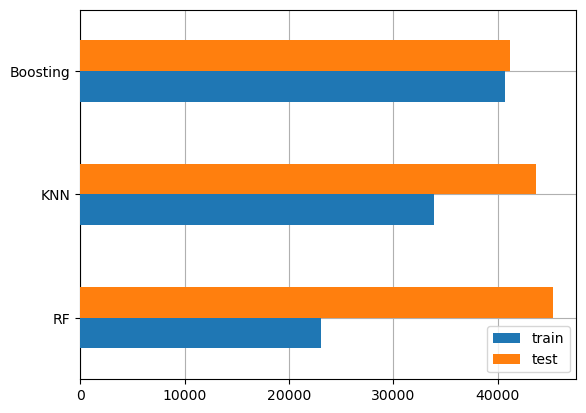

In [ ]:
fig, ax = plt.subplots()
mse.sort_values(by='test', ascending=False).plot(kind='barh', ax=ax, zorder=3)
ax.grid(zorder=0)

In [ ]:
prediksi = X_test.iloc[:1].copy()
pred_dict = {'y_true':y_test[:1]}
for name, model in model_dict.items():
    pred_dict['prediksi_'+name] = model.predict(prediksi).round(3)

pd.DataFrame(pred_dict)

,y_true,prediksi_KNN,prediksi_RF,prediksi_Boosting
778,5934.3798,5937.69,5956.881,8798.411
